# Gene Mutation Analysis for Commenticius Biotech Firm 
Commenticius research emphasises the use of mutant genes as therapeutics for infectious diseases. This notebook analyses 49 mutation screening data files to identify 5 top genes that can be further experimented on. 
Each file contains 
- Gene name 
- Wild type gene sequence *promoter and coding region included*
- Mutant DNA gene sequence *promoter and coding region included* 
- Normalised Cell Viability in 3 replicates 
- Normalised mRNA expression in 3 replicates 
- Normalised Protein expression in 3 replicates 

## Pre-Analytical Workflow
Prior to analysis of the data, I outlined the tasks in a chronological order and the neccessary conditions that would produce results and accomplish the goal of the project , which is to Identify top 5 genes in the data file. 
### Thought Process
I developed a realistic workflow by creating hypotheses with a mathematical approach, rather than a biological one. By this approach, I was able to create a logical task flow
1. Extract all the data and place in a single Dataframe 
2. Mathematically define the classes of mutaion ie. Substitution,Insertion and Deletion
3. Aggregate the data; which simply means create a summary of the data
4. Create or implement a mathematical standard that highlightes the best genes based on latest findings
5. Reach a conclusion with all the data found 

This analysis was perfomed by Esan Ifeoluwa, a bioinformatics consultant with student number 52428445, using Python version 3.12.9, along with the necessary associated tools and libraries for the entire process.

## Analysis Workflow

### Import Required Libraries

Import libraries such as os, pandas, matplotlib, and seaborn for data manipulation and visualization.

In [95]:
# Import Required Libraries
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Define Data Directory

Set the directory path where gene data files are stored and list all files in the directory.

In [96]:
# Define Data Directory
data_dir = Path("./data")
data_files = list(data_dir.iterdir())

In [97]:
# Load each text file into a DataFrame and store in a list
dfs = [pd.read_csv(file, sep="\t") for file in data_files]

print(f"Number of files loaded: {len(dfs)}")

Number of files loaded: 49


### Create a single dataframe using the columns as header
A Dataframe is a data structure that presents data in a spreadsheet form 

In [98]:
# Concatenate all DataFrames into a single DataFrame
df_con = pd.concat(dfs, ignore_index=True)
print(f"Number of rows in concatenated DataFrame: {len(df_con)}")

# Display the first few rows of the concatenated DataFrame
print("First few rows of the concatenated DataFrame:")
df_con.head()

Number of rows in concatenated DataFrame: 49
First few rows of the concatenated DataFrame:


,Gene,WildType.Sequence,Mutant.Sequence,mRNA.Expression.WT.Rep1,mRNA.Expression.WT.Rep2,mRNA.Expression.WT.Rep3,mRNA.Expression.Mut.Rep1,mRNA.Expression.Mut.Rep2,mRNA.Expression.Mut.Rep3,Protein.Expression.WT.Rep1,...,Protein.Expression.WT.Rep3,Protein.Expression.Mut.Rep1,Protein.Expression.Mut.Rep2,Protein.Expression.Mut.Rep3,CellViability.WT.Rep1,CellViability.WT.Rep2,CellViability.WT.Rep3,CellViability.Mut.Rep1,CellViability.Mut.Rep2,CellViability.Mut.Rep3
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,26.177081,16.735333,3.183135e+08,27.769621,17.761754,11685.0,...,37123.0,11693.0,26726.0,37133.0,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077
1,Alli2r,TTCTAACATGCGATCCTAGCGAGGGTTGTGTCGGACGTGAGCGGTG...,TTCTAACATGCGATCCTAGCGAGGGTTGTGTCGGACGTGAGCGGTG...,1.095715e+03,2.836341,102.980795,1.096189e+03,1.967358,103.294908,12831.0,...,23695.0,12848.0,28360.0,23705.0,0.638670,0.069546,0.052844,0.626906,0.193052,-0.124587
2,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,6.389135e+01,5.165643,13.914518,6.275914e+01,5.012645,13.013207,14317.0,...,42445.0,14334.0,4914.0,42448.0,0.062666,0.090101,0.256835,0.074965,0.163613,0.220555
3,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1.629126e+00,20.977798,7.266207,-3.674294e+00,-109.439914,-5.597223,25803.0,...,4047.0,8711.0,21503.0,0.0,0.528095,0.765748,0.273578,0.000000,0.000000,0.000000
4,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,3.619328e+00,7.207154,1.347365,3.898224e+00,6.585581,0.413255,44784.0,...,3517.0,44785.0,32607.0,3530.0,0.412541,0.059328,0.476712,0.184925,0.017589,0.460078


### Define Mutation Functions 

Define functions to classify mutations and calculate priority scores for genes.
The code created made the length of the DNA sequences between the wild-type sequences and mutant sequences as a determinant for what classifies a mutation. The length of the DNA sequences was derived from the biological definition of classes of mutation which is further expressed in the table below:

|Mutation Class               | Biological Definition | Mathematical Definition | Code  |
|-----------------------|-----------------------|-------------------------|---------------------|
| Substitution          | Replaces one base with another base   | Lengths are equal       | No change in sequence |
| Insertion             | Add one or more bases to the sequence | Mutant length > WT      |'len(wt_seq) < len(mut_seq)' |
| Deletion              | Remove one or more bases from thr sequence | WT length > Mutant   | 'len(wt_seq) > len(mut_seq)' |

This creates the 'Mutation Type' dataframe
In order to determine the location of mutation, the promoter region and the coding region must be defined. The promoter region is the first 1000 nucleotides of the sequence. 
This creates a dataframe named 'Mutation Location'
that means any change found in the first 1000 nucleotides is located in the promoter region and any found else where is in the coding region. 

**Promoter region** is a specific region where the protein RNA polymerase binds to initiate transcription process.
**Coding region** is a part of the DNA sequence that contains the instruction for making the protein.


In [99]:



def classify_mutation(wt_seq, mut_seq):
    """
    Classifies the type and location of a mutation based on the wild-type and mutant sequences.

    Parameters:
        wt_seq (str): The wild-type DNA sequence.
        mut_seq (str): The mutant DNA sequence.

    Returns:
        tuple: A tuple containing the mutation type ('insertion', 'deletion', 'substitution', or 'none')
            and the mutation location ('promoter', 'coding', or 'none').
    """
    if wt_seq == mut_seq:
        return "none", "none"

    location = "promoter" if wt_seq[:1000] != mut_seq[:1000] else "coding"

    if len(wt_seq) < len(mut_seq):
        mut_type = "insertion"
    elif len(wt_seq) > len(mut_seq):
        mut_type = "deletion"
    else:
        mut_type = "substitution"

    return mut_type, location


def calculate_priority_score(row):
    """
    calculate_priority_score(row):
        Calculates a priority score for a gene based on differences in viability, mRNA, protein expression,
        and mutation characteristics.

        Parameters:
            row (pd.Series): A row from a DataFrame containing gene metrics and mutation details.

        Returns:
            int: The calculated priority score for the gene.
    """
    score = 0
    if row["Viability_Diff"] > 0:
        score += 2
    elif row["Viability_Diff"] == 0:
        score += 1
    if row["mRNA_Diff"] > 0:
        score += 1
    if row["Protein_Diff"] > 0:
        score += 1
    if row["Mutation_Location"] == "promoter":
        score += 1
    if row["Mutation_Type"] == "substitution":
        score += 1
    return score

### Aggregate Data from Files

Loop through each file, extract metrics, classify mutations, and store the aggregated data in a DataFrame.

In [100]:
# Apply mutation classification
df_con["Mutation_Type"], df_con["Mutation_Location"] = zip(
    *df_con.apply(lambda row: classify_mutation(row[1], row[2]), axis=1)
)

# Compute means and diffs directly across rows
df_con["Mean_WT_mRNA"] = df_con.iloc[:, 3:6].mean(axis=1)
df_con["Mean_Mut_mRNA"] = df_con.iloc[:, 6:9].mean(axis=1)
df_con["mRNA_Diff"] = df_con["Mean_Mut_mRNA"] - df_con["Mean_WT_mRNA"]

df_con["Mean_WT_Protein"] = df_con.iloc[:, 9:12].mean(axis=1)
df_con["Mean_Mut_Protein"] = df_con.iloc[:, 12:15].mean(axis=1)
df_con["Protein_Diff"] = df_con["Mean_Mut_Protein"] - df_con["Mean_WT_Protein"]

df_con["Mean_WT_Viability"] = df_con.iloc[:, 15:18].mean(axis=1)
df_con["Mean_Mut_Viability"] = df_con.iloc[:, 18:21].mean(axis=1)
df_con["Viability_Diff"] = df_con["Mean_Mut_Viability"] - df_con["Mean_WT_Viability"]

C:\Users\IFEOLUWA\AppData\Local\Temp\ipykernel_18796\2397863814.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  *df_con.apply(lambda row: classify_mutation(row[1], row[2]), axis=1)


### Create a New data frame Highlighting New Data Headers 

In [101]:

aggregated_df = df_con[
    [
        "Gene",
        "Mutation_Type",
        "Mutation_Location",
        "Mean_WT_mRNA",
        "Mean_Mut_mRNA",
        "mRNA_Diff",
        "Mean_WT_Protein",
        "Mean_Mut_Protein",
        "Protein_Diff",
        "Mean_WT_Viability",
        "Mean_Mut_Viability",
        "Viability_Diff",
    ]
]
# create a folder and save the new data frame
output_dir = Path("./output")
output_dir.mkdir(exist_ok=True)
aggregated_df.to_csv("./output/classified_aggregated_table.csv", index=False)

In [102]:
aggregated_df

,Gene,Mutation_Type,Mutation_Location,Mean_WT_mRNA,Mean_Mut_mRNA,mRNA_Diff,Mean_WT_Protein,Mean_Mut_Protein,Protein_Diff,Mean_WT_Viability,Mean_Mut_Viability,Viability_Diff
0,Ah3,substitution,promoter,1.061045e+08,1.061045e+08,1.083121,25176.666667,25184.000000,7.333333,0.540463,0.599650,0.059187
1,Alli2r,insertion,promoter,4.005106e+02,4.004839e+02,-0.026733,21626.666667,21637.666667,11.000000,0.253687,0.231790,-0.021896
2,Alli8,substitution,promoter,2.765717e+01,2.692833e+01,-0.728842,20556.333333,20565.333333,9.000000,0.136534,0.153044,0.016510
3,Anap7c1,substitution,promoter,9.957710e+00,-3.957048e+01,-49.528187,21147.666667,10071.333333,-11076.333333,0.522474,0.000000,-0.522474
4,App1l8,insertion,promoter,4.057949e+00,3.632353e+00,-0.425596,26965.333333,26974.000000,8.666667,0.316194,0.220864,-0.095330
5,App8,substitution,promoter,2.435471e+00,2.497834e+00,0.062362,16175.666667,16183.000000,7.333333,0.433318,0.355784,-0.077533
6,Avon1a5,substitution,promoter,7.714530e+01,7.751793e+01,0.372632,22752.333333,22765.666667,13.333333,0.535115,0.585167,0.050052
7,Avon4,insertion,promoter,2.512790e+00,3.958356e+00,1.445566,35318.333333,55350.000000,20031.666667,0.642143,5.857854,5.215711
8,Ben3l6,insertion,promoter,8.745566e+02,8.746048e+02,0.048286,11301.333333,11314.333333,13.000000,0.244863,0.307827,0.062964
9,Bma9,insertion,promoter,3.100805e+01,3.162820e+01,0.620151,20849.333333,20864.000000,14.666667,0.446393,0.308237,-0.138156


## Post- Analytical Workflow 

At this point, the aggregates of data has been obtained. The main task is further analysis for presentation and conclusions purposes. Inorder to get inferences from the data above. In order to determine the the top genes, there has to be a ranking system.
A ranking system must consist of 
1. Characteristics of the gene that are relevant to Commenticius for further experimental validation.
2. A set of parameters set that define the rank of the genes 
3. Assigned values used to implement the ranking system. 



### Score and Rank Genes

Apply a scoring system to prioritize genes and identify the top 5 candidates

In [103]:
# Score and Rank Genes
# Head Highlights the first 5 genes in the DataFrame 
aggregated_df = aggregated_df.copy()


aggregated_df["Priority_Score"] = aggregated_df.apply(calculate_priority_score, axis=1)
top_5_genes = (
    aggregated_df.sort_values(by="Priority_Score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

### Data Visualisation 

Create multi-panel plots to visualize the distribution of key metrics across mutation classes. The plots used to create graphs are the box plot, scatter plot and the kernel density plot.

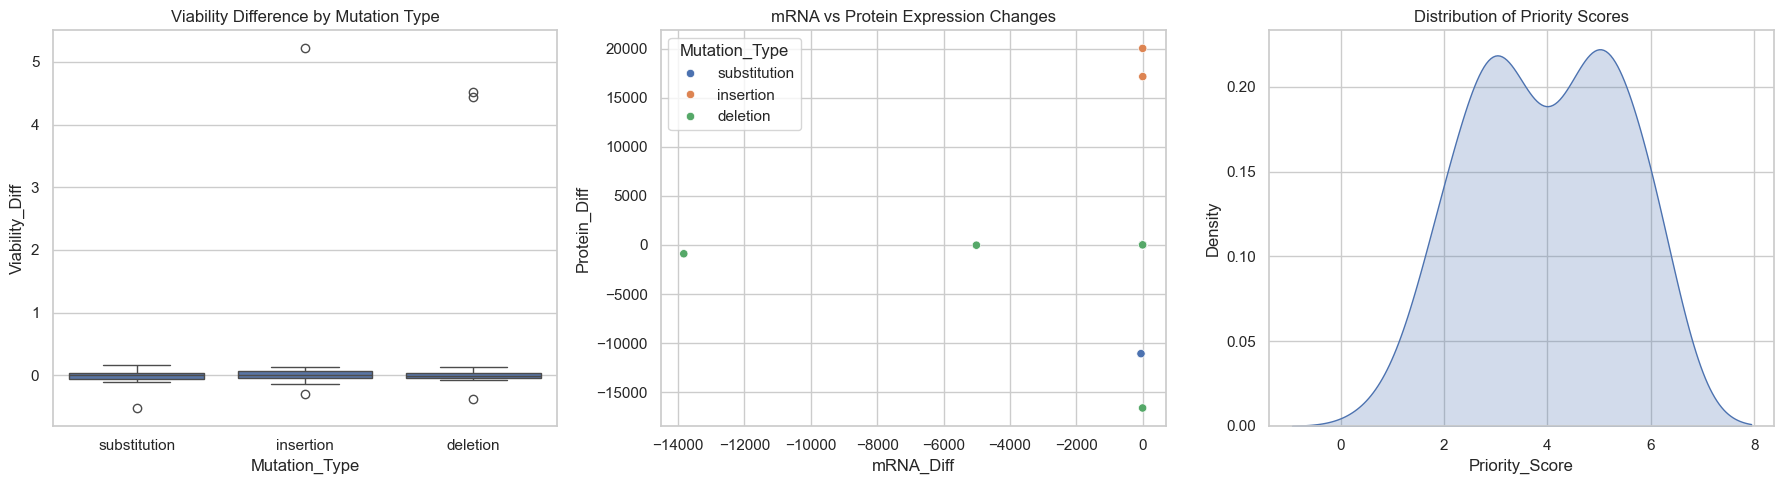

In [104]:
# Visualize Results
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot of Viability by Mutation Type
sns.boxplot(x="Mutation_Type", y="Viability_Diff", data=aggregated_df, ax=axs[0])
axs[0].set_title("Viability Difference by Mutation Type")

# Scatter Plot: mRNA vs. Protein Change
sns.scatterplot(
    x="mRNA_Diff", y="Protein_Diff", hue="Mutation_Type", data=aggregated_df, ax=axs[1]
)
axs[1].set_title("mRNA vs Protein Expression Changes")

# KDE plot of Priority Scores
sns.kdeplot(data=aggregated_df["Priority_Score"], fill=True, ax=axs[2])
axs[2].set_title("Distribution of Priority Scores")

plt.tight_layout()
plt.show()

### Display Top 5 Genes

Display a table of the top 5 gene candidates for experimental validation.

In [105]:
# Display Top 5 Genes
top_5_genes
# Save Top 5 Genes to CSV
top_5_genes.to_csv("./output/top_5_genes.csv", index=False)

### Filter the DataFrame with a Strict Criteria 
A Priority score defines the ranking system, adding a strict criteria creates a filter that is based on the parameters 
Using a strict criterion ensures that only genes with consistently positive differences in viability, mRNA, and protein expression are selected, highlighting the most promising candidates with robust and reliable performance for the company.


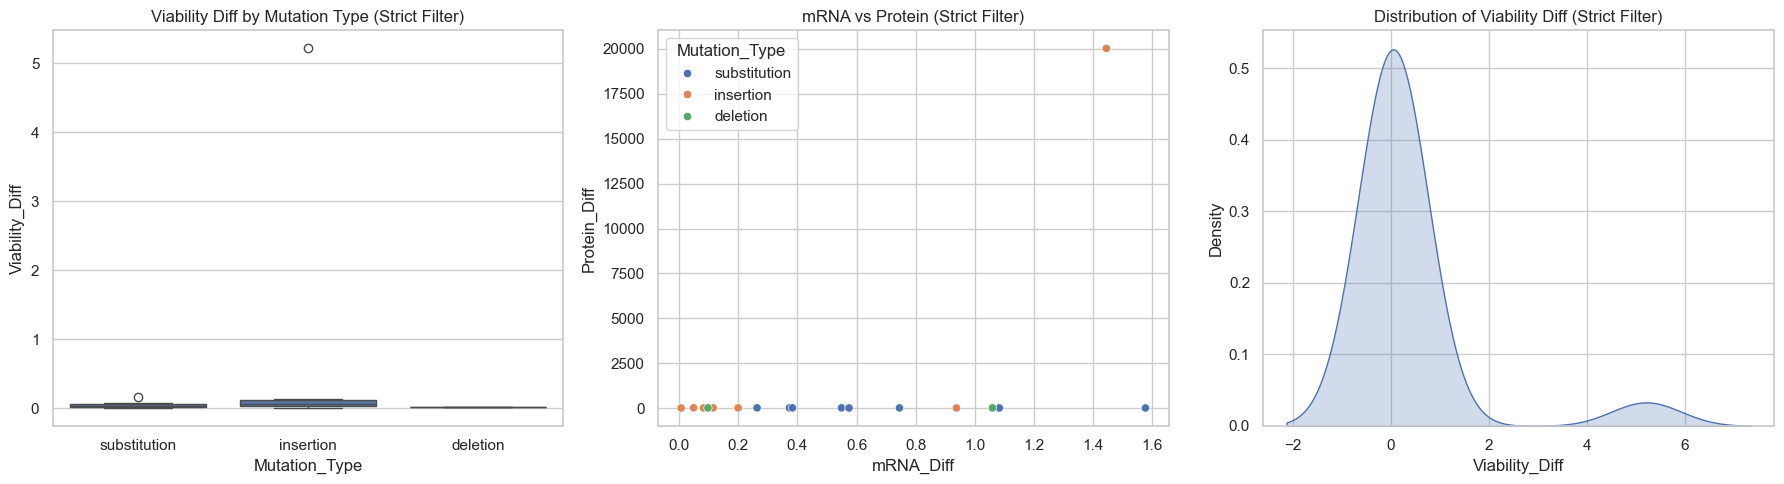

In [106]:
# Filter for strict criteria: all differences must be positive
strict_df = aggregated_df[
    (aggregated_df["Viability_Diff"] > 0)
    & (aggregated_df["mRNA_Diff"] > 0)
    & (aggregated_df["Protein_Diff"] > 0)
].copy()

# Sort and extract top 5 genes by viability difference
top5_strict = (
    strict_df.sort_values(by="Viability_Diff", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

# Visualize these genes
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot of Viability Diff by Mutation Type
sns.boxplot(x="Mutation_Type", y="Viability_Diff", data=strict_df, ax=axs[0])
axs[0].set_title("Viability Diff by Mutation Type (Strict Filter)")

# Scatter Plot of mRNA vs Protein Diff
sns.scatterplot(
    x="mRNA_Diff", y="Protein_Diff", hue="Mutation_Type", data=strict_df, ax=axs[1]
)
axs[1].set_title("mRNA vs Protein (Strict Filter)")

# KDE of Viability Diff
sns.kdeplot(strict_df["Viability_Diff"], fill=True, ax=axs[2])
axs[2].set_title("Distribution of Viability Diff (Strict Filter)")

plt.tight_layout()
plt.show()

In [107]:
# Display Top 5 Genes with Strict Criteria

# Save Top 5 Genes with Strict Criteria to CSV
top5_strict.to_csv("./output/top_5_genes_strict.csv", index=False)
top5_strict

,Gene,Mutation_Type,Mutation_Location,Mean_WT_mRNA,Mean_Mut_mRNA,mRNA_Diff,Mean_WT_Protein,Mean_Mut_Protein,Protein_Diff,Mean_WT_Viability,Mean_Mut_Viability,Viability_Diff,Priority_Score
0,Avon4,insertion,promoter,2.512790,3.958356,1.445566,35318.333333,55350.000000,20031.666667,0.642143,5.857854,5.215711,5
1,Daz2b7,substitution,promoter,80.601283,81.346445,0.745162,30539.666667,30548.333333,8.666667,0.580531,0.751425,0.170895,6
2,Euk4r4,insertion,promoter,30.930392,30.936469,0.006077,23740.333333,23746.333333,6.000000,0.545242,0.680983,0.135741,5
3,Everr1,insertion,promoter,195.390905,195.472721,0.081817,12922.000000,12928.666667,6.666667,0.557876,0.666745,0.108869,5
4,Cairn3a2,substitution,promoter,25.366828,25.749749,0.382921,28437.666667,28449.666667,12.000000,0.702936,0.775747,0.072811,6


## Conclusion 
 The Top 5 genes chosen for further validation were selected using a strict criteria. A Strict criteria filters out the dataframe based on values set. I set the filter to obtain based on cell viability, mRNA and Protein Expression. Cell Viability is the measure of active cells in the sample, and is an important factor in drug screening assays. mRNA and protein expressions give insight to how the gene woud interact against diseases and mechanisms of action. Setting positive differneces 
ensures that only genes with consistently positive differences in viability, mRNA, and protein expression are selected. This approach highlights the most promising candidates with robust and reliable performance for further experimental validation.
By selecting genes with consistently positive differences, we ensure that only the most promising candidates with robust and reliable performance are highlighted for further experimental validation. Positive differences indicate an improvement or enhancement in these metrics, making these genes ideal candidates for therapeutic exploration.

## Appendix
### GIT HUB REPOSITORY
[ESAN_IFE_52428445_BTECH_COMPUTATION](https://github.com/Ifefay/BT5511ESANCODE)
### AI Tools used 
- Chat GPT [OpenAI](https://www.openai.com)
<div style="color:yellow"> ChatGPT prompt used <bold>"Write a Python function classify_mutation(wt_seq, mut_seq) that takes two DNA sequences as input: a wild-type sequence (wt_seq) and a mutant sequence (mut_seq)"</bold></div>

- Chat GPT [OpenAI](https://www.openai.com)
<div style="color:yellow"> ChatGPT prompt used <bold>"The function should classify the type of mutation and its location in the DNA sequence The location should be classified as either 'promoter' (for mutations in the first 1000 base pairs of the sequence) or 'coding' (for mutations beyond the first 1000 base pairs), or 'none' if there is no mutation."</bold></div>

- Chat GPT [OpenAI](https://www.openai.com)
<div style="color:yellow"> ChatGPT prompt used <bold>"How to I create a ranking system to rank the genes create to get top 5 genes "</bold></div>

- CoPilot [CoPilot](https://copilot.github.com/)
<div style="color:yellow"> ChatGPT prompt used <bold>"Create a markdown table with four rows and fow columns  "</bold></div>

- Chat GPT [OpenAI](https://www.openai.com)
<div style="color:yellow"> ChatGPT prompt used <bold>"How do I improve the priority score to highlight the cell viability "</bold></div>



### Supplementary Materials  
- Python for Biologists by Dr Martin Jones 
- Two ways of Counting Nucleotides in DNA [YouTube](https://www.youtube.com/watch?v=rql_5TfP05o)
- Biopython Tutorial and Cookbook by Je Chang, Brad Chapman, Iddo Friedberg, Thomas Hamelryck,
 Michiel de Hoon, Peter Cock, Tiago Antao, Eric Talevich, Bartek Wilczynski

